# Credit Card Default Risk Analysis

## 1. Data Loading and Initial Inspection

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, roc_curve, roc_auc_score, precision_recall_curve, average_precision_score
from sklearn.model_selection import cross_val_predict

In [3]:
df = pd.read_excel("../data/default of credit card clients.xls",header=1)

In [4]:
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [5]:
df.shape

(30000, 25)

## 2. Data Types and Summary Statistics

This section provides an initial overview of the dataset, including its dimensions, structure, data types, and summary statistics.

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   ID                          30000 non-null  int64
 1   LIMIT_BAL                   30000 non-null  int64
 2   SEX                         30000 non-null  int64
 3   EDUCATION                   30000 non-null  int64
 4   MARRIAGE                    30000 non-null  int64
 5   AGE                         30000 non-null  int64
 6   PAY_0                       30000 non-null  int64
 7   PAY_2                       30000 non-null  int64
 8   PAY_3                       30000 non-null  int64
 9   PAY_4                       30000 non-null  int64
 10  PAY_5                       30000 non-null  int64
 11  PAY_6                       30000 non-null  int64
 12  BILL_AMT1                   30000 non-null  int64
 13  BILL_AMT2                   30000 non-null  int64
 14  BILL_AMT3        

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,30000.0,15000.500000,8660.398374,1.0,7500.75,15000.5,22500.25,30000.0
LIMIT_BAL,30000.0,167484.322667,129747.661567,10000.0,50000.00,140000.0,240000.00,1000000.0
SEX,30000.0,1.603733,0.489129,1.0,1.00,2.0,2.00,2.0
EDUCATION,30000.0,1.853133,0.790349,0.0,1.00,2.0,2.00,6.0
MARRIAGE,30000.0,1.551867,0.521970,0.0,1.00,2.0,2.00,3.0
AGE,30000.0,35.485500,9.217904,21.0,28.00,34.0,41.00,79.0
PAY_0,30000.0,-0.016700,1.123802,-2.0,-1.00,0.0,0.00,8.0
PAY_2,30000.0,-0.133767,1.197186,-2.0,-1.00,0.0,0.00,8.0
PAY_3,30000.0,-0.166200,1.196868,-2.0,-1.00,0.0,0.00,8.0
PAY_4,30000.0,-0.220667,1.169139,-2.0,-1.00,0.0,0.00,8.0


In [8]:
df.isna().sum()

ID                            0
LIMIT_BAL                     0
SEX                           0
EDUCATION                     0
MARRIAGE                      0
AGE                           0
PAY_0                         0
PAY_2                         0
PAY_3                         0
PAY_4                         0
PAY_5                         0
PAY_6                         0
BILL_AMT1                     0
BILL_AMT2                     0
BILL_AMT3                     0
BILL_AMT4                     0
BILL_AMT5                     0
BILL_AMT6                     0
PAY_AMT1                      0
PAY_AMT2                      0
PAY_AMT3                      0
PAY_AMT4                      0
PAY_AMT5                      0
PAY_AMT6                      0
default payment next month    0
dtype: int64

In [9]:
df[df.duplicated()]

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month


## 3. Data Quality & Categorical Encoding Verification

The encoded categorical and repayment-status variables are examined to identify their unique values and frequency distributions.

In [10]:
demographic_columns = [
    "SEX",
    "EDUCATION",
    "MARRIAGE"
]

repayment_columns = [
    "PAY_0",
    "PAY_2",
    "PAY_3",
    "PAY_4",
    "PAY_5",
    "PAY_6"
]

In [11]:
for column in demographic_columns:
    print("=" * 50)
    print(df[column].value_counts())

SEX
2    18112
1    11888
Name: count, dtype: int64
EDUCATION
2    14030
1    10585
3     4917
5      280
4      123
6       51
0       14
Name: count, dtype: int64
MARRIAGE
2    15964
1    13659
3      323
0       54
Name: count, dtype: int64


In [12]:
for column in repayment_columns:
    print("=" * 50)
    print(df[column].value_counts())

PAY_0
 0    14737
-1     5686
 1     3688
-2     2759
 2     2667
 3      322
 4       76
 5       26
 8       19
 6       11
 7        9
Name: count, dtype: int64
PAY_2
 0    15730
-1     6050
 2     3927
-2     3782
 3      326
 4       99
 1       28
 5       25
 7       20
 6       12
 8        1
Name: count, dtype: int64
PAY_3
 0    15764
-1     5938
-2     4085
 2     3819
 3      240
 4       76
 7       27
 6       23
 5       21
 1        4
 8        3
Name: count, dtype: int64
PAY_4
 0    16455
-1     5687
-2     4348
 2     3159
 3      180
 4       69
 7       58
 5       35
 6        5
 1        2
 8        2
Name: count, dtype: int64
PAY_5
 0    16947
-1     5539
-2     4546
 2     2626
 3      178
 4       84
 7       58
 5       17
 6        4
 8        1
Name: count, dtype: int64
PAY_6
 0    16286
-1     5740
-2     4895
 2     2766
 3      184
 4       49
 7       46
 6       19
 5       13
 8        2
Name: count, dtype: int64


Demographics (`SEX`, `EDUCATION`, `MARRIAGE`): Identified undocumented categories (e.g., `0, 5, 6` in `EDUCATION` and `0` in `MARRIAGE`). These will be regrouped into an "Others/Unknown" category during preprocessing.

Repayment Status (`PAY_0` to `PAY_6`): Identified undocumented `-2` and `0` values. In credit risk analysis, `-2` typically indicates no balance/no consumption, and `0` indicates revolving credit usage.

## 4. Exploratory Data Analysis (EDA)

### 4-1. Target Distribution

The distribution of the target variable is examined to determine the number and proportion of clients who defaulted and those who did not default on their next payment.

In [13]:
target_distribution = df["default payment next month"].value_counts()

target_percentage = (
    df["default payment next month"]
    .value_counts(normalize=True)
    .mul(100)
)

target_summary = pd.DataFrame({
    "Count": target_distribution,
    "Percentage": target_percentage
})

target_summary

,Count,Percentage
default payment next month,,
0,23364,77.88
1,6636,22.12


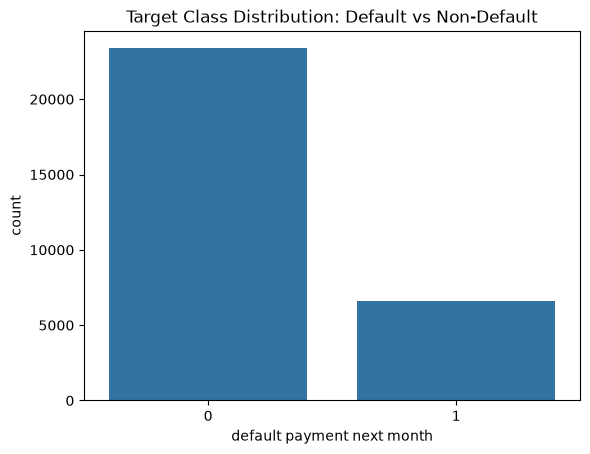

In [90]:
sns.countplot(data=df, x="default payment next month")
plt.title("Target Class Distribution: Default vs Non-Default")
plt.savefig("../figures/target_distribution.png", bbox_inches="tight", dpi=150)

The target is moderately imbalanced. Approximately 78% of clients did not default, while about 22% defaulted. This imbalance means that Accuracy alone is not sufficient and we will need to evaluate the model using Precision, Recall, F1-score, ROC-AUC and PR-AUC.

### 4-2. Credit Limit

In [15]:
df["LIMIT_BAL"].agg(['mean', 'median', 'min', 'max'])

mean       167484.322667
median     140000.000000
min         10000.000000
max       1000000.000000
Name: LIMIT_BAL, dtype: float64

Text(0.5, 1.0, 'Distribution of Credit Limit (LIMIT_BAL)')

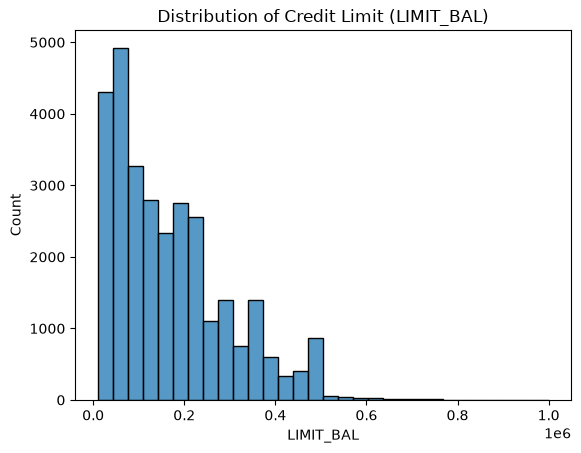

In [83]:
sns.histplot(data=df, x="LIMIT_BAL", bins=30)
plt.title("Distribution of Credit Limit (LIMIT_BAL)")

Text(0.5, 1.0, 'Credit Limit Distribution by Default Status')

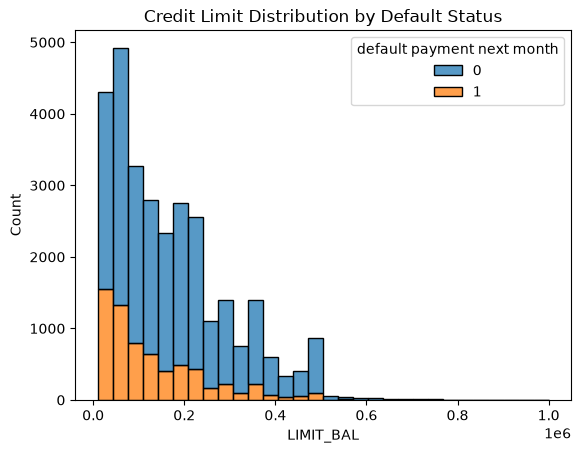

In [84]:
sns.histplot(data=df, x="LIMIT_BAL", hue="default payment next month", bins=30, multiple="stack")
plt.title("Credit Limit Distribution by Default Status")

In [18]:
df.groupby("default payment next month")["LIMIT_BAL"].agg(['mean', 'median', 'min', 'max'])

,mean,median,min,max
default payment next month,,,,
0,178099.726074,150000.0,10000,1000000
1,130109.656420,90000.0,10000,740000


Credit limit is right-skewed. Default clients are more concentrated in the lower credit-limit range compared to non-default clients. This suggests that lower credit limits are associated with higher default risk.

### 4-3. AGE

Text(0.5, 1.0, 'Distribution of Client Age')

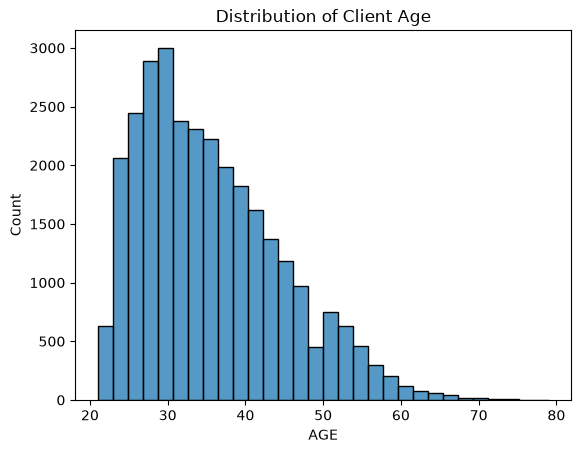

In [85]:
sns.histplot(data=df, x="AGE", bins=30)
plt.title("Distribution of Client Age")

Text(0.5, 1.0, 'Age Distribution by Default Status')

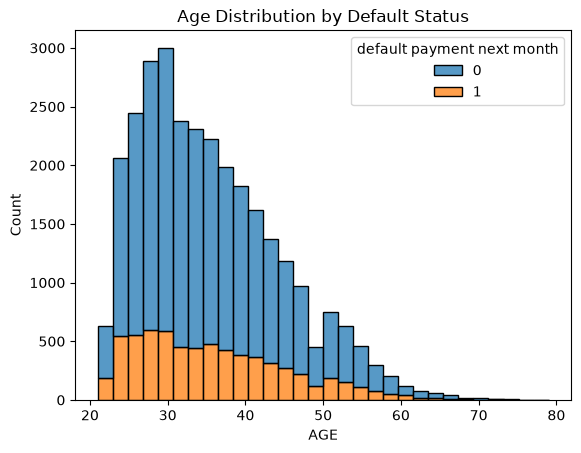

In [86]:
sns.histplot(data=df, x="AGE", hue="default payment next month", bins=30, multiple="stack")
plt.title("Age Distribution by Default Status")

In [21]:
df.groupby("default payment next month")["AGE"].agg(['mean', 'median', 'min', 'max'])

,mean,median,min,max
default payment next month,,,,
0,35.417266,34.0,21,79
1,35.725738,34.0,21,75


The age distribution is very similar between default and non-default groups. Mean and median ages are almost identical. Age does not provide strong separation and is unlikely to be a powerful predictor on its own.

### 4-4. Repayment Status

In [22]:
repayment_columns

['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']

In [23]:
for column in repayment_columns:
    print("=" * 50)
    print(df.groupby(column)["default payment next month"].mean()*100)

PAY_0
-2    13.229431
-1    16.778051
 0    12.811291
 1    33.947939
 2    69.141357
 3    75.776398
 4    68.421053
 5    50.000000
 6    54.545455
 7    77.777778
 8    57.894737
Name: default payment next month, dtype: float64
PAY_2
-2    18.270756
-1    15.966942
 0    15.912270
 1    17.857143
 2    55.614973
 3    61.656442
 4    50.505051
 5    60.000000
 6    75.000000
 7    60.000000
 8     0.000000
Name: default payment next month, dtype: float64
PAY_3
-2    18.531212
-1    15.594476
 0    17.451155
 1    25.000000
 2    51.557999
 3    57.500000
 4    57.894737
 5    57.142857
 6    60.869565
 7    81.481481
 8    66.666667
Name: default payment next month, dtype: float64
PAY_4
-2    19.250230
-1    15.895903
 0    18.328775
 1    50.000000
 2    52.326686
 3    61.111111
 4    66.666667
 5    51.428571
 6    40.000000
 7    82.758621
 8    50.000000
Name: default payment next month, dtype: float64
PAY_5
-2     19.687637
-1     16.194259
 0     18.852894
 2     54.188880
 3

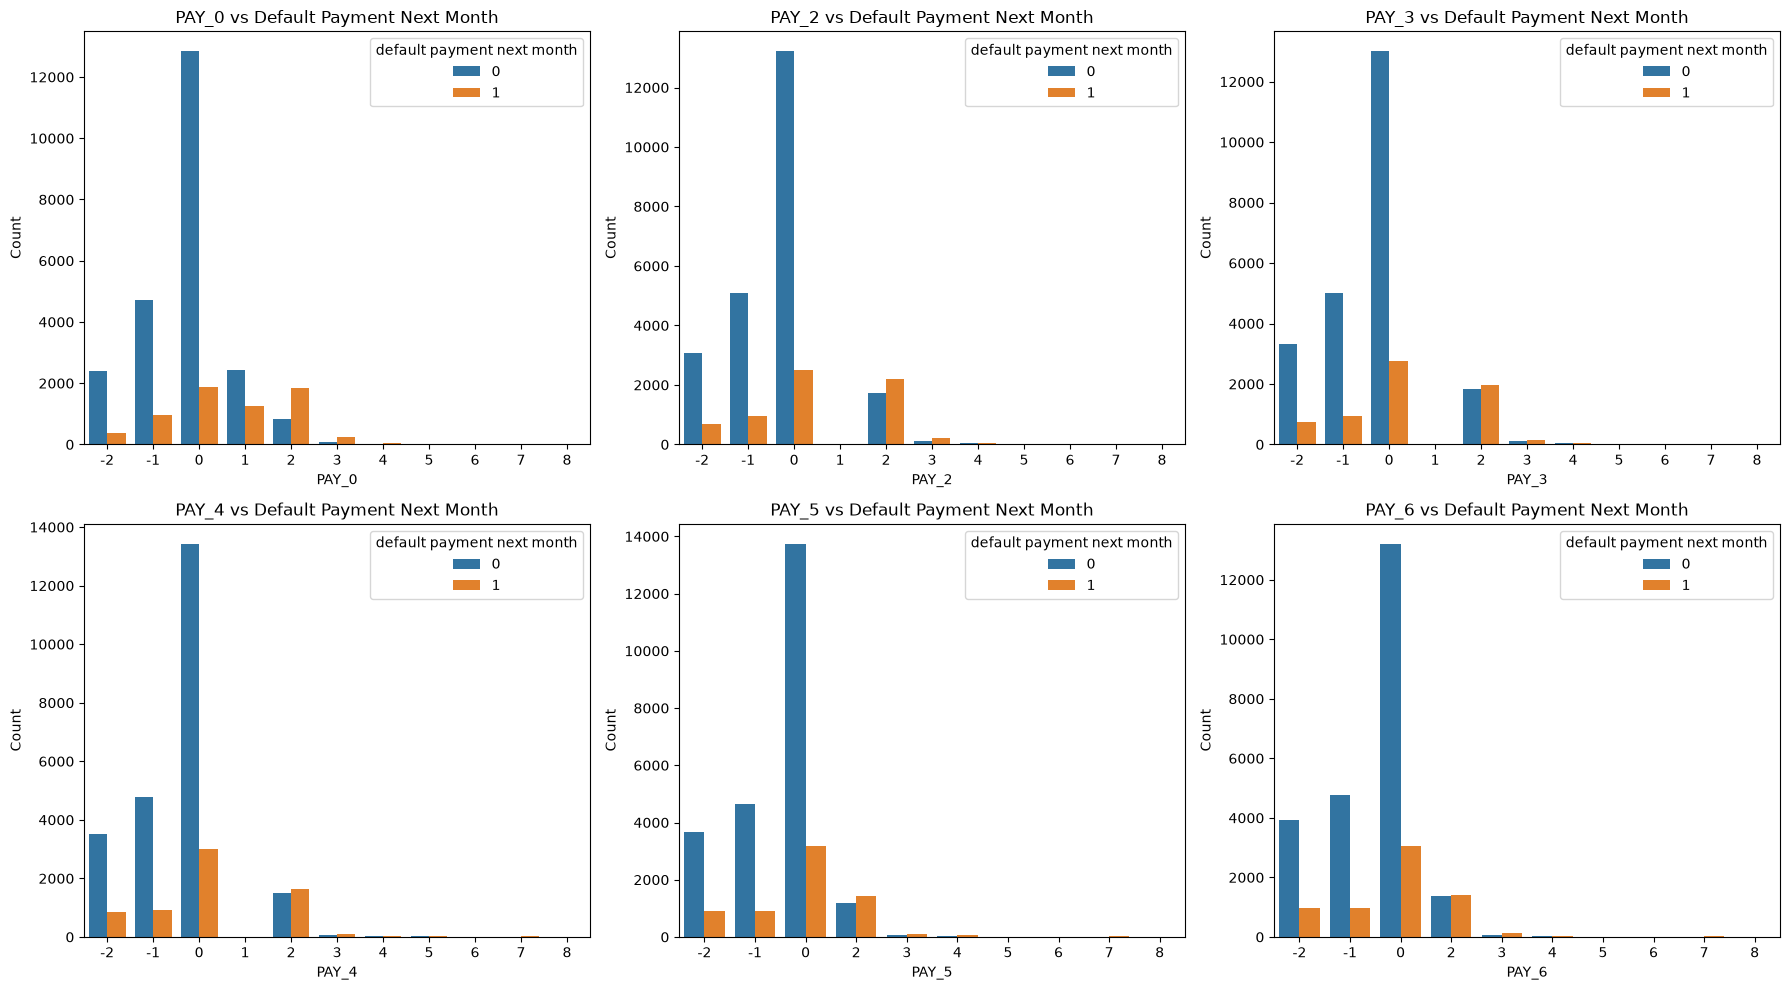

In [91]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for column, ax in zip(repayment_columns, axes.flat):
    sns.countplot(
        data=df,
        x=column,
        hue="default payment next month",
        ax=ax
    )
    
    ax.set_title(f"{column} vs Default Payment Next Month")
    ax.set_xlabel(column)
    ax.set_ylabel("Count")

plt.tight_layout()
fig.savefig("../figures/repayment_status_comparison.png", bbox_inches="tight", dpi=150)

PAY_0 shows a clear and strong relationship with default. Clients with status 0 have a low default rate (≈13%), while clients with status 2 or higher have a much higher default rate (often above 60–70%). This is one of the most informative variables in the dataset.

### 4-5. Bill Statement Amount

In [25]:
bill_amt = ["BILL_AMT1", "BILL_AMT2", "BILL_AMT3", "BILL_AMT4", "BILL_AMT5", "BILL_AMT6"]

In [26]:
for column in bill_amt:
    print("=" * 50)
    print(f"{column}")
    print(df.groupby("default payment next month")[column].agg(['mean', 'median']))

BILL_AMT1
                                    mean   median
default payment next month                       
0                           51994.227273  23119.5
1                           48509.162297  20185.0
BILL_AMT2
                                    mean   median
default payment next month                       
0                           49717.435670  21660.5
1                           47283.617842  20300.5
BILL_AMT3
                                    mean   median
default payment next month                       
0                           47533.365605  20202.5
1                           45181.598855  19834.5
BILL_AMT4
                                    mean   median
default payment next month                       
0                           43611.165254  19000.0
1                           42036.950573  19119.5
BILL_AMT5
                                    mean   median
default payment next month                       
0                           40530.445343  17998.0


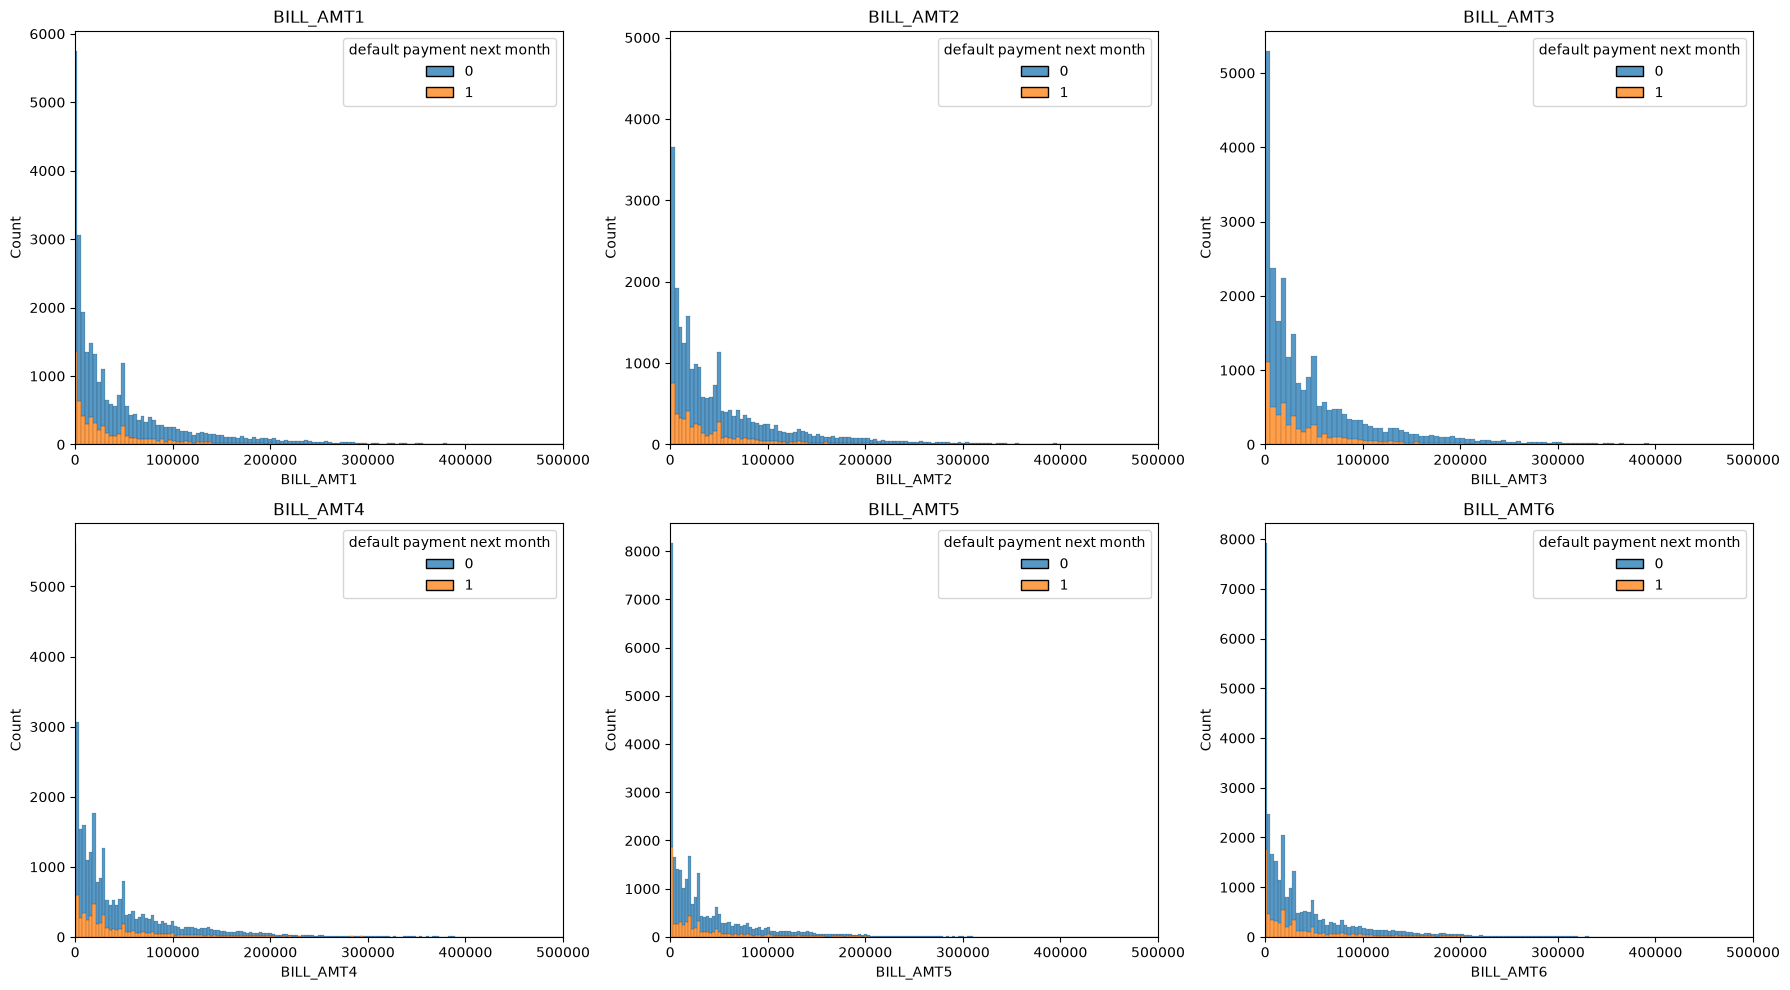

In [92]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for column, ax in zip(bill_amt, axes.flat):
    sns.histplot(
        data=df,
        x=column,
        hue="default payment next month",
        multiple="stack",
        ax=ax
    )
    ax.set_xlim(0,0.5*1e6)
    ax.set_title(f"{column}")
    ax.set_xlabel(column)
    ax.set_ylabel("Count")

plt.tight_layout()
fig.savefig("../figures/bill_amount_by_target.png", bbox_inches="tight", dpi=150)

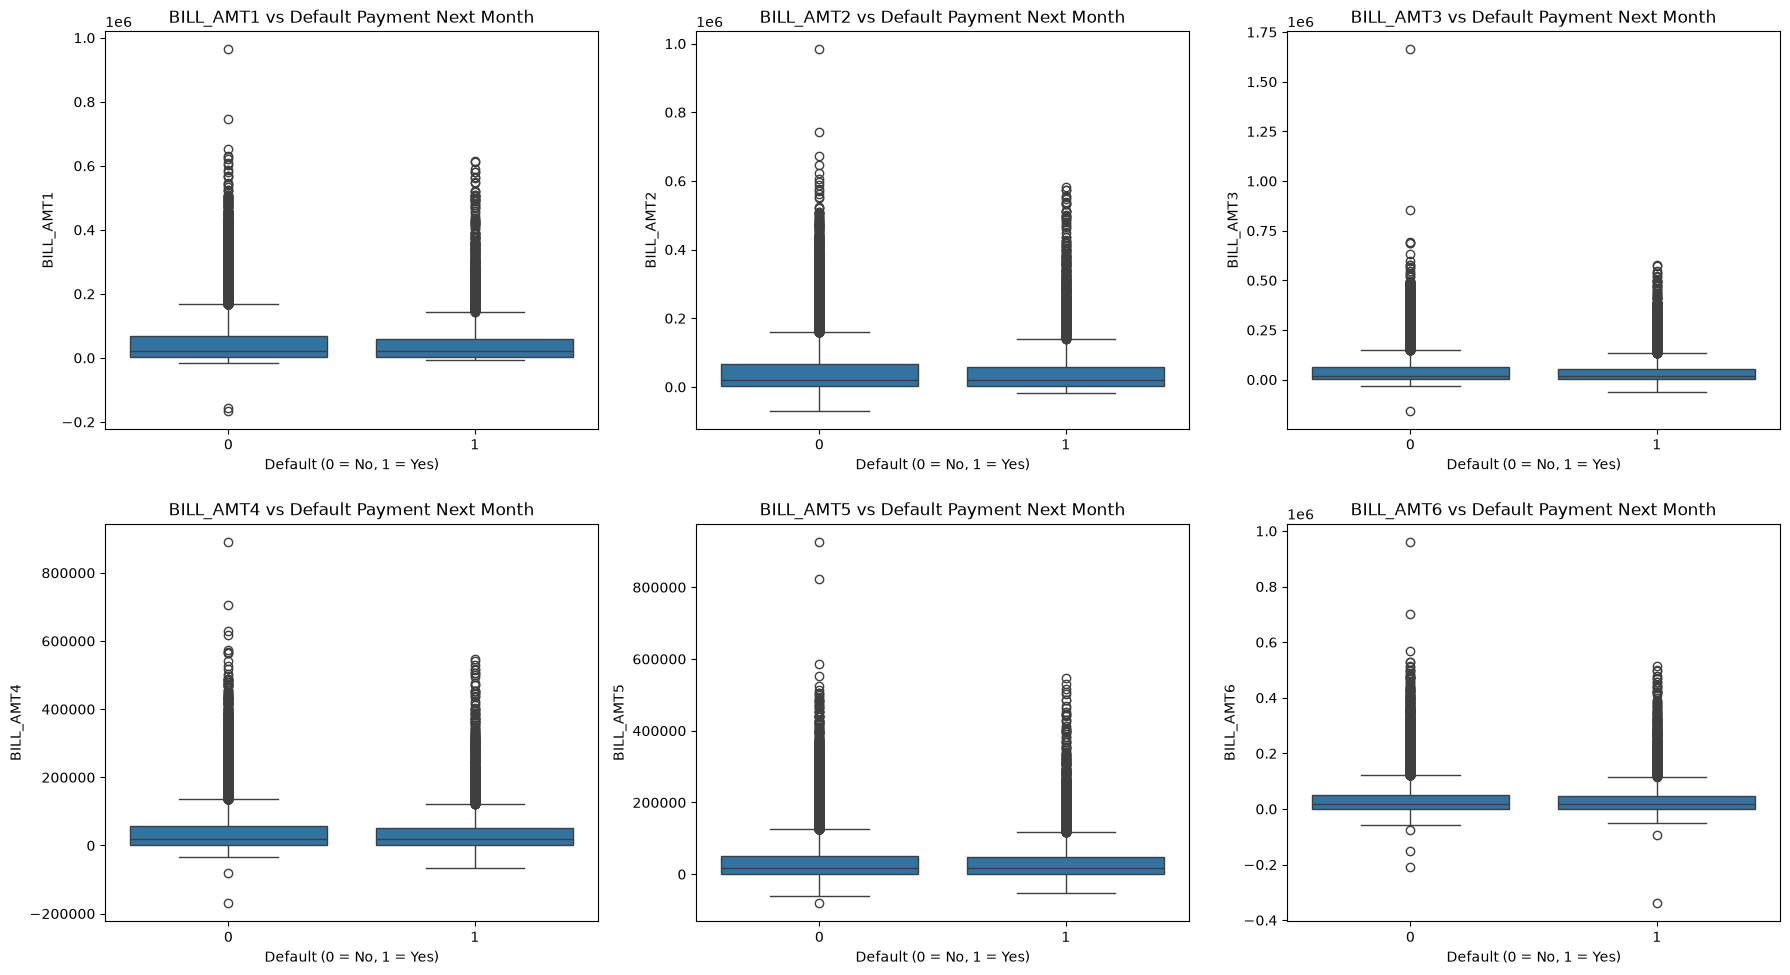

In [28]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for column, ax in zip(bill_amt, axes.flat):
    sns.boxplot(
        data=df,
        x="default payment next month",
        y=column,
        ax=ax
    )
    ax.set_title(f"{column} vs Default Payment Next Month")
    ax.set_xlabel("Default (0 = No, 1 = Yes)")
    ax.set_ylabel(column)

plt.tight_layout()

### 4-6. Previous Payment Amount

In [29]:
pay_amt = ["PAY_AMT1", "PAY_AMT2", "PAY_AMT3", "PAY_AMT4", "PAY_AMT5", "PAY_AMT6"]

In [30]:
for column in pay_amt:
    print("=" * 50)
    print(f"{column}")
    print(df.groupby("default payment next month")[column].agg(['mean', 'median']))

PAY_AMT1
                                   mean  median
default payment next month                     
0                           6307.337357  2459.5
1                           3397.044153  1636.0
PAY_AMT2
                                   mean  median
default payment next month                     
0                           6640.465074  2247.5
1                           3388.649638  1533.5
PAY_AMT3
                                   mean  median
default payment next month                     
0                           5753.496833  2000.0
1                           3367.351567  1222.0
PAY_AMT4
                                   mean  median
default payment next month                     
0                           5300.529319  1734.0
1                           3155.626733  1000.0
PAY_AMT5
                                   mean  median
default payment next month                     
0                           5248.220296  1765.0
1                           3219.139542  10

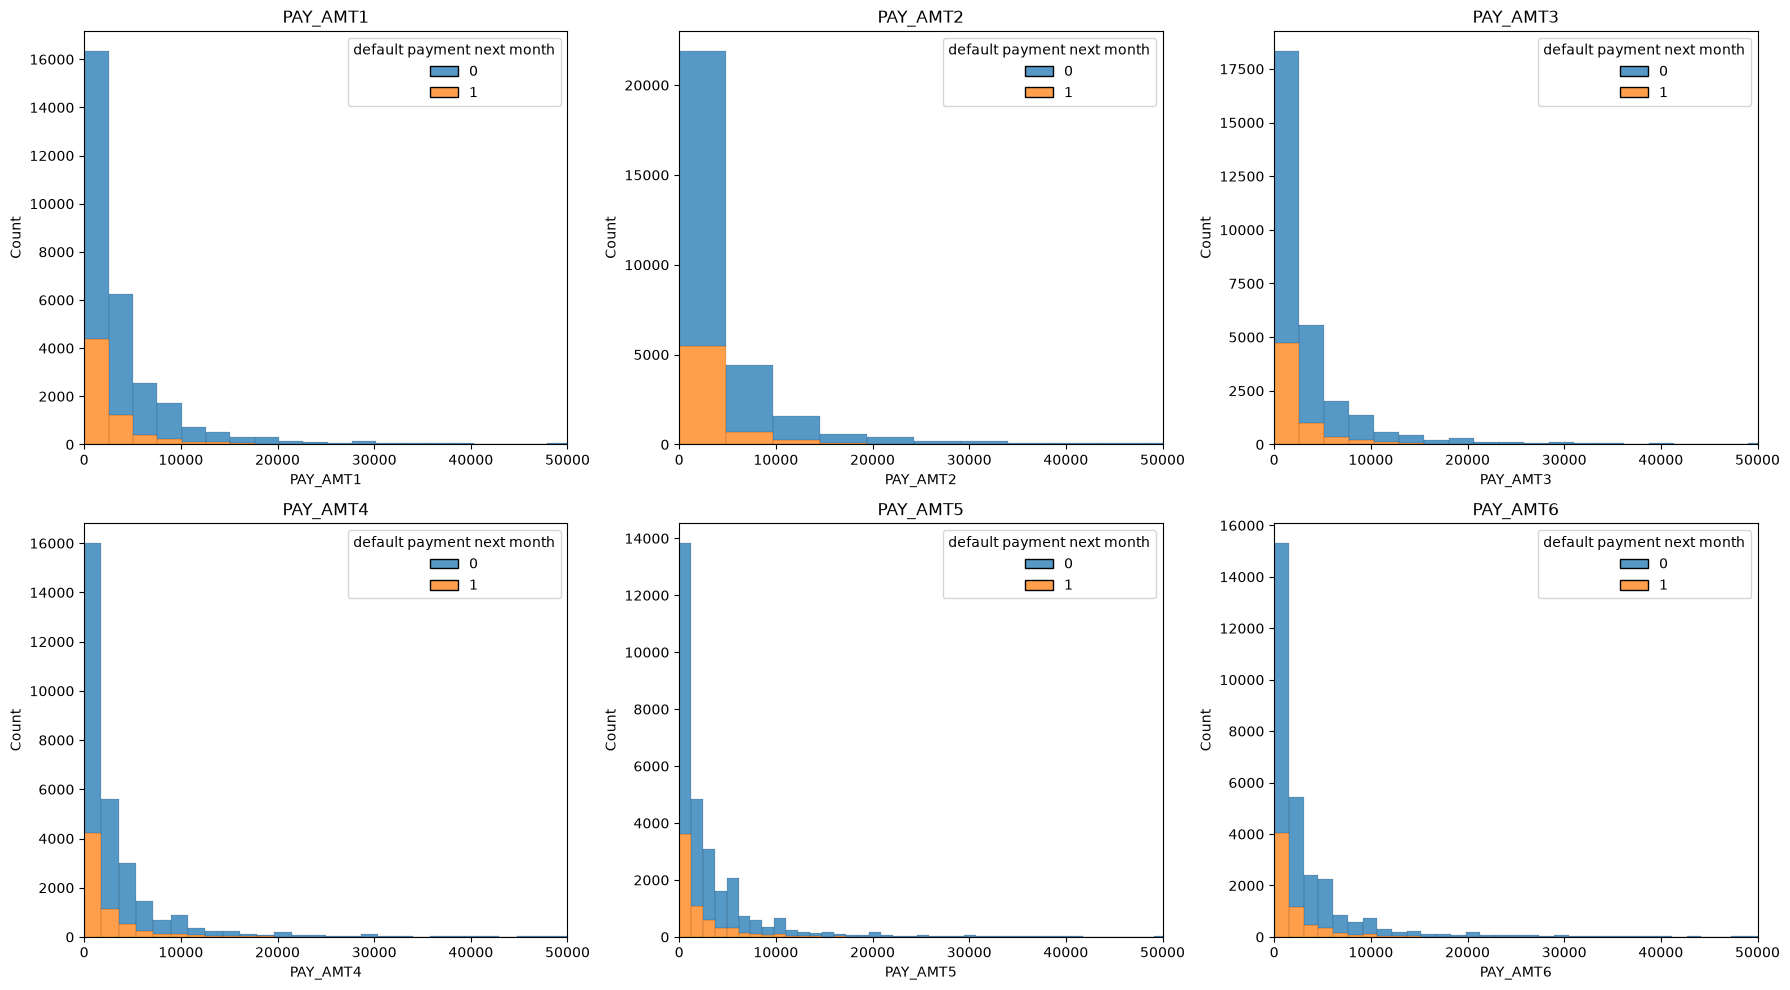

In [31]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for column, ax in zip(pay_amt, axes.flat):
    sns.histplot(
        data=df,
        x=column,
        hue="default payment next month",
        multiple="stack",
        ax=ax
    )
    ax.set_xlim(0,0.5*1e5)
    ax.set_title(f"{column}")
    ax.set_xlabel(column)
    ax.set_ylabel("Count")

plt.tight_layout()

Average bill amount (BILL_AMT1) is only slightly lower for default clients. In contrast, the average payment amount (PAY_AMT1) is substantially lower for default clients. Recent payment behavior appears more informative than the bill amount itself.

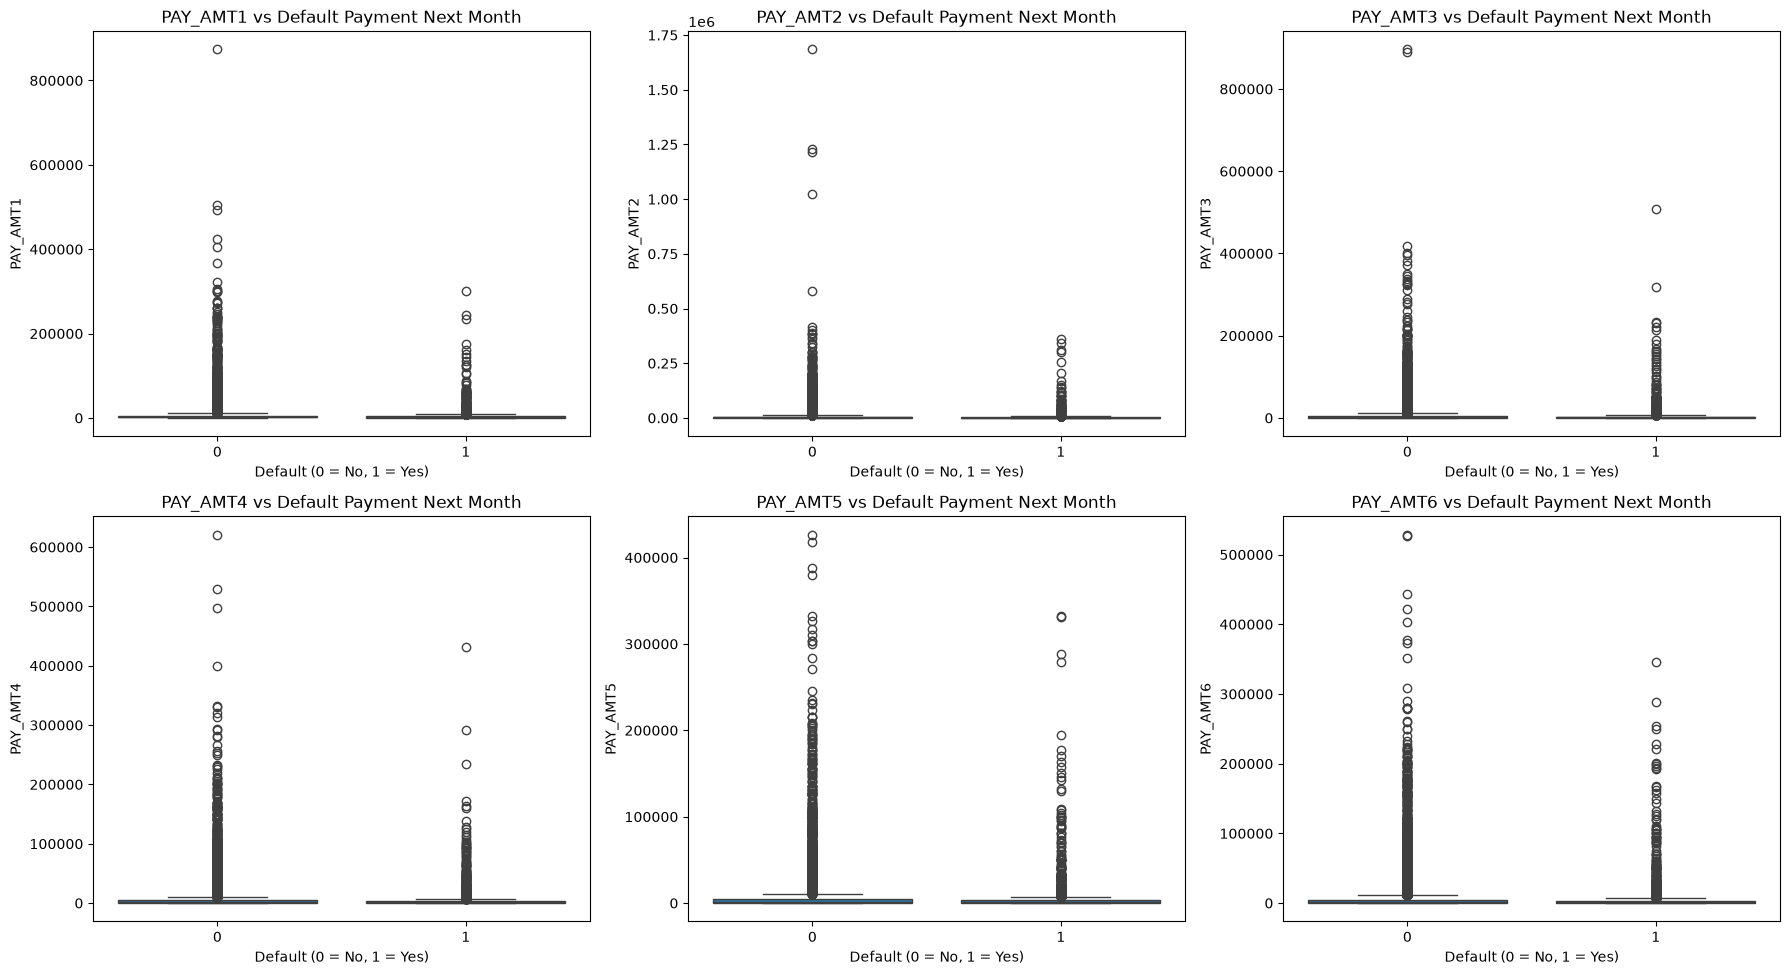

In [93]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for column, ax in zip(pay_amt, axes.flat):
    sns.boxplot(
        data=df,
        x="default payment next month",
        y=column,
        ax=ax
    )
    ax.set_title(f"{column} vs Default Payment Next Month")
    ax.set_xlabel("Default (0 = No, 1 = Yes)")
    ax.set_ylabel(column)

plt.tight_layout()
fig.savefig("../figures/payment_amount_by_target.png", bbox_inches="tight", dpi=150)

Across all six months, average bill amounts (BILL_AMT1-6) are only slightly lower for default clients compared to non-default clients. In contrast, average payment amounts (PAY_AMT1-6) are consistently and substantially lower for default clients across every month. This pattern is strongest in the most recent months and persists throughout the six-month window, suggesting that recent payment behavior is more informative for predicting default than the bill amount itself.

### 4-7. Demographic Variables

In [33]:
for column in demographic_columns:
    print("=" * 50)
    print(df.groupby(column)["default payment next month"].mean() * 100)

SEX
1    24.167227
2    20.776281
Name: default payment next month, dtype: float64
EDUCATION
0     0.000000
1    19.234766
2    23.734854
3    25.157616
4     5.691057
5     6.428571
6    15.686275
Name: default payment next month, dtype: float64
MARRIAGE
0     9.259259
1    23.471704
2    20.928339
3    26.006192
Name: default payment next month, dtype: float64


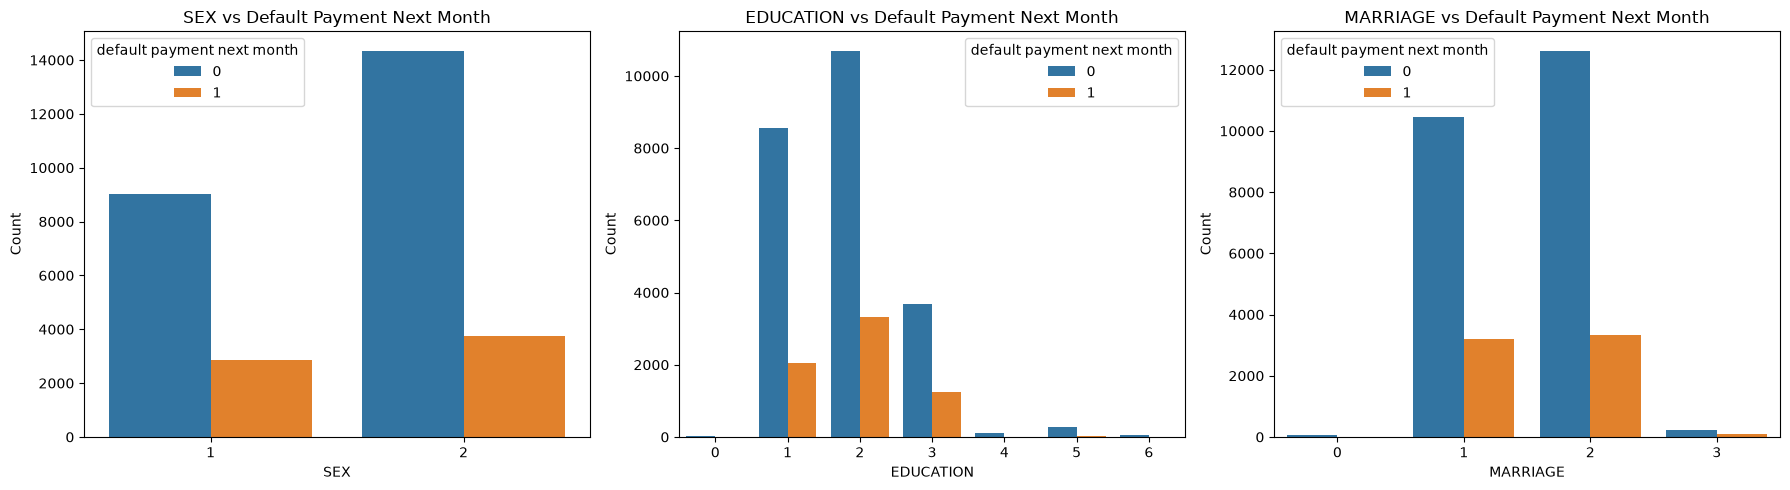

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for column, ax in zip(demographic_columns, axes.flat):
    sns.countplot(
        data=df,
        x=column,
        hue="default payment next month",
        ax=ax
    )
    
    ax.set_title(f"{column} vs Default Payment Next Month")
    ax.set_xlabel(column)
    ax.set_ylabel("Count")

plt.tight_layout()

SEX shows a small difference in default rate between the two groups, with male clients showing a slightly higher default rate than female clients. EDUCATION shows some variation across categories, with lower education levels associated with a somewhat higher default rate. MARRIAGE shows a modest difference as well. Overall, demographic variables show weaker separation between default and non-default groups compared to repayment status, suggesting they may act as secondary rather than primary predictors.

### Key Insights & Takeaways for Modeling

This EDA section addresses Q1 (portfolio profile before modeling), Q2 (differences between default and non-default groups) and Q3 (most informative recent repayment behaviors) from the project brief. Key findings for modeling:

* **Target Imbalance:** ~22.1% default rate, requiring evaluation beyond Accuracy (PR-AUC, ROC-AUC, Recall).
* **Top Predictors:** Repayment status (`PAY_0` to `PAY_6`) provides the strongest signal, with recent delay (`PAY_0`) being most critical.
* **Skewed Distributions:** `BILL_AMT` and `PAY_AMT` show extreme right-skewness; StandardScaler was used for the baseline model, though log transformation could be explored as a future refinement.
* **Feature Engineering Opportunities (not implemented in this baseline):**
  * **Utilization Rate:** `BILL_AMT / LIMIT_BAL`
  * **Payment Ratio:** `PAY_AMT / BILL_AMT`
  * **Trend Metrics:** Max and average payment delay over time.

## 5. Preprocessing

### 5-1. Handling Undocumented Categorical Values

The undocumented values identified earlier in `EDUCATION` (`0`, `5`, `6`) are regrouped under a single code (`0`), representing an "Unknown" category, since it is not clear whether these values correspond to genuine "Others" responses or missing/invalid entries. In `MARRIAGE`, the undocumented value `0` is already isolated from the documented categories (`1`, `2`, `3`) and is treated as "Unknown" without further transformation.

This regrouping is a fixed, rule-based transformation and is applied before the train/test split, so it does not introduce data leakage.

In [35]:
df["EDUCATION"] = df["EDUCATION"].replace({
    5: 0,
    6: 0
})

In [36]:
df["EDUCATION"].value_counts()

EDUCATION
2    14030
1    10585
3     4917
0      345
4      123
Name: count, dtype: int64

### 5-2. Feature and Target Separation

The `ID` column is dropped as it is a unique identifier with no predictive value. The target variable (`default payment next month`) is separated into `y`, and the remaining columns form the feature matrix `X`.

In [37]:
df.drop("ID", axis=1, inplace=True)

In [38]:
X = df.drop("default payment next month", axis=1)
y = df["default payment next month"]

### 5-3. Encoding Categorical Variables

The nominal categorical variables (`SEX`, `EDUCATION`, `MARRIAGE`) are one-hot encoded to avoid implying a false ordinal relationship between their category codes. The repayment-status variables (`PAY_0` to `PAY_6`) are kept in their original numeric/ordinal form, consistent with common practice for this dataset.

The repayment-status variables (`PAY_0` to `PAY_6`) are kept in their original numeric form rather than being one-hot encoded, since their values represent an ordinal degree of payment delay (e.g., higher values indicate longer delays). Encoding them as dummy variables would discard this ordinal information.

In [39]:
X = pd.get_dummies(X, columns = ['SEX', 'EDUCATION', 'MARRIAGE'], drop_first=True)

In [40]:
X.columns

Index(['LIMIT_BAL', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5',
       'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4',
       'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3',
       'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'SEX_2', 'EDUCATION_1',
       'EDUCATION_2', 'EDUCATION_3', 'EDUCATION_4', 'MARRIAGE_1', 'MARRIAGE_2',
       'MARRIAGE_3'],
      dtype='str')

In [41]:
X.shape[0]

30000

## 6. Train/Test Split

The dataset is split into training and test sets using a stratified split to preserve the original class distribution in both sets, given the class imbalance identified during EDA. A fixed random seed is used to ensure reproducibility.

In [42]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

In [43]:
X_train.shape

(21000, 28)

In [44]:
X_test.shape

(9000, 28)

## 7. Feature Scaling

Numerical features are standardized using a scaler fit only on the training data, and then applied to both the training and test sets. This prevents information from the test set from leaking into the preprocessing step.

In [45]:
fea_for_scaling = ['LIMIT_BAL', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5',
       'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4',
       'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3',
       'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']

In [46]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train[fea_for_scaling])
X_test_scaled = scaler.transform(X_test[fea_for_scaling])

X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=fea_for_scaling, index=X_train.index)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=fea_for_scaling, index=X_test.index)

X_train_final = X_train.drop(columns=fea_for_scaling)
X_test_final = X_test.drop(columns=fea_for_scaling)

X_train_final = pd.concat([X_train_scaled_df, X_train_final], axis=1)
X_test_final = pd.concat([X_test_scaled_df, X_test_final], axis=1)

In [47]:
X_train_final.shape

(21000, 28)

In [48]:
X_test_final.shape

(9000, 28)

In [49]:
X_train_final

,LIMIT_BAL,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,...,PAY_AMT5,PAY_AMT6,SEX_2,EDUCATION_1,EDUCATION_2,EDUCATION_3,EDUCATION_4,MARRIAGE_1,MARRIAGE_2,MARRIAGE_3
11018,-0.057791,-0.373240,0.013521,0.111565,0.138827,0.189478,0.240862,0.253727,1.424699,1.505293,...,0.077888,0.015063,True,False,True,False,False,False,True,False
1710,-0.520169,-0.590997,0.013521,0.111565,0.138827,0.189478,2.020319,0.253727,-0.309799,-0.228184,...,-0.130219,-0.186865,True,True,False,False,False,False,True,False
4618,-0.674295,-0.699875,0.013521,0.111565,0.138827,0.189478,0.240862,0.253727,0.305950,0.367929,...,-0.212433,-0.205902,False,True,False,False,False,False,True,False
5482,-1.136673,-0.917632,0.013521,0.111565,-0.698439,-0.671226,-1.538595,-1.492102,-0.596318,-0.660204,...,-0.318004,-0.296554,True,False,True,False,False,True,False,False
26187,-0.905484,-0.590997,-1.766735,-1.555358,-1.535704,-1.531931,-1.538595,-1.492102,-0.695269,-0.661469,...,-0.318004,-0.296554,True,True,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25780,0.250461,-0.373240,0.013521,0.111565,-1.535704,-1.531931,-1.538595,-1.492102,-0.549939,-0.690558,...,-0.318004,-0.296554,True,False,True,False,False,True,False,False
13921,-0.366043,-1.244266,0.013521,0.111565,0.138827,0.189478,0.240862,1.999557,0.830367,0.902323,...,-0.017126,-0.296554,True,False,True,False,False,False,True,False
3794,-0.366043,-1.244266,0.013521,0.111565,0.138827,0.189478,0.240862,0.253727,0.334117,0.377499,...,-0.238826,-0.239897,True,True,False,False,False,False,True,False
27565,1.483469,2.348718,0.903650,-1.555358,-0.698439,-0.671226,-0.648866,-1.492102,-0.695269,-0.690558,...,-0.318004,-0.296554,False,True,False,False,False,True,False,False


## 8. Baseline Model: Logistic Regression

A Logistic Regression model is fit on the training data as the required baseline classifier for this project(Q4). Both class predictions and predicted default probabilities are generated, as the probabilities will be used later for threshold analysis and risk segmentation.

In [50]:
lr_model = LogisticRegression(random_state=42)
lr_model.fit(X_train_final,y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solve

In [51]:
lr_y_pred = lr_model.predict(X_test_final)
lr_y_proba = lr_model.predict_proba(X_test_final)[:,1]

## 9. Evaluation Metrics Interpretation

In [52]:
lr_cm = confusion_matrix(y_test, lr_y_pred)
print(lr_cm)
print(classification_report(y_test, lr_y_pred))

[[6805  204]
 [1514  477]]
              precision    recall  f1-score   support

           0       0.82      0.97      0.89      7009
           1       0.70      0.24      0.36      1991

    accuracy                           0.81      9000
   macro avg       0.76      0.61      0.62      9000
weighted avg       0.79      0.81      0.77      9000



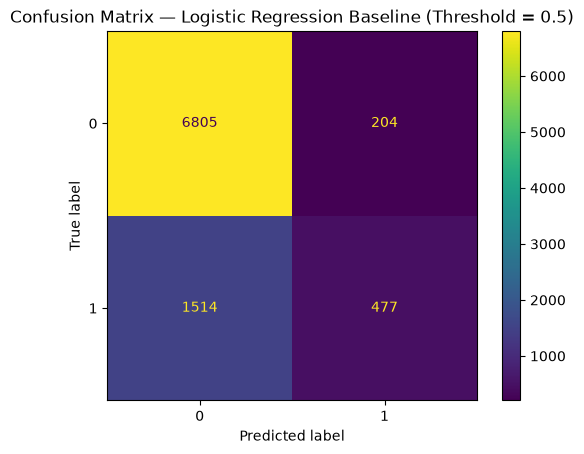

In [94]:
ConfusionMatrixDisplay(lr_cm).plot()
plt.title("Confusion Matrix — Logistic Regression Baseline (Threshold = 0.5)")
plt.savefig("../figures/confusion_matrix.png", bbox_inches="tight", dpi=150)

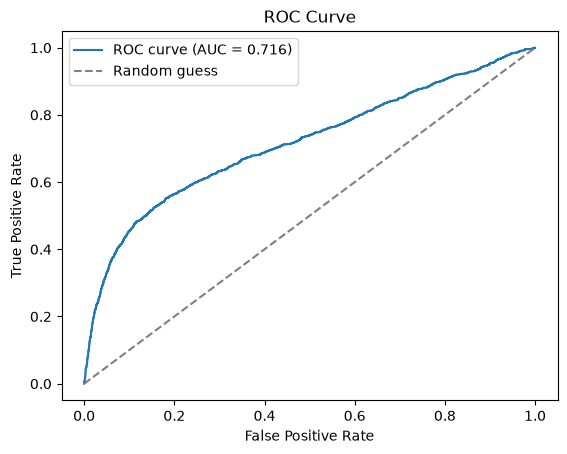

In [95]:
fpr, tpr, thresholds_roc = roc_curve(y_test, lr_y_proba)
roc_auc = roc_auc_score(y_test, lr_y_proba)

plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.savefig("../figures/roc_curve.png", bbox_inches="tight", dpi=150)

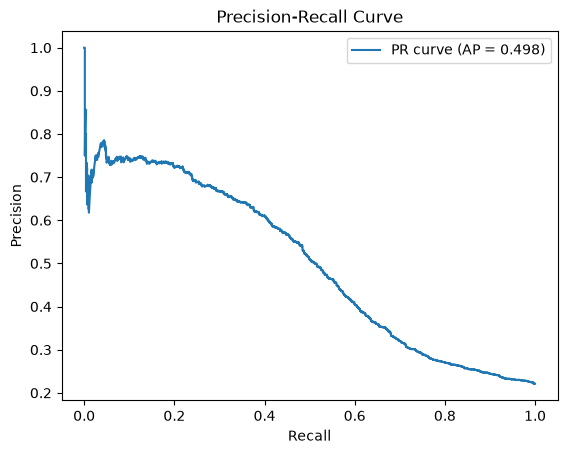

In [96]:
precision, recall, thresholds_pr = precision_recall_curve(y_test, lr_y_proba)
pr_auc = average_precision_score(y_test, lr_y_proba)

plt.plot(recall, precision, label=f"PR curve (AP = {pr_auc:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.savefig("../figures/pr_curve.png", bbox_inches="tight", dpi=150)

With the default 0.5 threshold, the baseline Logistic Regression correctly identifies only 24% of clients who actually default (Recall = 0.24), while achieving 70% Precision for the default class. This means the model misses a large share of true defaulters (1,514 false negatives out of 1,991 actual defaulters), which is a critical business concern.

Accuracy alone (0.81) is misleading here: a naive model that always predicts "no default" would achieve roughly 78% accuracy without any real predictive value, since defaults represent only ~22% of clients.

ROC-AUC (0.716) indicates moderate overall discriminative ability. PR-AUC (0.498) is more informative for this imbalanced problem, since it is substantially higher than the PR-AUC of a random classifier (~0.221, equal to the positive class rate). This confirms the model carries meaningful signal beyond class prevalence, even though its practical recall at the default threshold is currently low.(Q5)

These results motivate exploring alternative classification thresholds (Q9) and business-driven risk segmentation (Q7), rather than relying on the default 0.5 cutoff.

## 10. Threshold Comparison (Q9)

In [56]:
cv_proba = cross_val_predict(lr_model, X_train_final, y_train, cv=5, method="predict_proba")[:, 1]

In [57]:
def evaluate_threshold(y_true, y_proba, threshold):
    y_pred_custom = (y_proba >= threshold).astype(int)
    
    cm = confusion_matrix(y_true, y_pred_custom)
    report = classification_report(y_true, y_pred_custom, output_dict=True)
    
    return {
        "threshold": threshold,
        "precision": report["1"]["precision"],
        "recall": report["1"]["recall"],
        "f1": report["1"]["f1-score"],
        "confusion_matrix": cm
    }

thresholds_to_test = [0.2, 0.3, 0.4, 0.5, 0.7]

results_cv = []
for t in thresholds_to_test:
    result = evaluate_threshold(y_train, cv_proba, t)
    results_cv.append(result)

comparison_df_cv = pd.DataFrame([
    {"threshold": r["threshold"], "precision": r["precision"], "recall": r["recall"], "f1": r["f1"]}
    for r in results_cv
])
comparison_df_cv

,threshold,precision,recall,f1
0,0.2,0.331608,0.703552,0.450759
1,0.3,0.571504,0.468891,0.515137
2,0.4,0.644732,0.386006,0.482898
3,0.5,0.707570,0.249516,0.368932
4,0.7,0.742537,0.042842,0.081010


In [58]:
final_threshold = 0.3
final_result = evaluate_threshold(y_test, lr_y_proba, final_threshold)
print(final_result["confusion_matrix"])
print(f"Precision: {final_result['precision']:.3f}, Recall: {final_result['recall']:.3f}, F1: {final_result['f1']:.3f}")

[[6302  707]
 [1084  907]]
Precision: 0.562, Recall: 0.456, F1: 0.503


To avoid tuning the threshold on the test set, classification thresholds were compared using out-of-fold probabilities from 5-fold cross-validation on the training data. Lowering the threshold from the default 0.5 substantially increases Recall at the cost of Precision, with F1-score maximized around threshold = 0.3.

Threshold = 0.3 was selected and evaluated once on the untouched test set, confirming consistent performance (Precision = 0.562, Recall = 0.456, F1 = 0.503). Compared to the default 0.5 threshold, this shift reduces missed defaulters from 1,514 to 1,084 false negatives, at the cost of increasing false positives from 204 to 707 — a trade-off discussed further in Q6. The close agreement between cross-validation and test-set results confirms the threshold was chosen without leaking information from the test set.

## 11. False Negatives vs. False Positives (Q6)

In this business context, a false negative (a defaulting client predicted as low-risk) is generally more costly than a false positive (a non-defaulting client flagged as risky). A missed defaulter typically results in a direct financial loss on the outstanding credit amount, whereas a false positive mainly incurs an operational cost, such as a manual review or a courtesy check-in with a client who was never actually at risk.

This asymmetry is reflected in the threshold comparison from Q9: lowering the threshold from 0.5 to 0.3 reduced missed defaulters from 1,514 to 1,084 (a meaningful reduction in potential losses), at the cost of increasing false positives from 204 to 707 (additional review workload on clients who would not have defaulted). Given the likely cost asymmetry, this trade-off is favorable, and Recall for the default class (along with PR-AUC) should be prioritized as the key metric to monitor, rather than Accuracy or Precision alone.

This reasoning assumes false negatives are more costly than false positives, which is a simplifying assumption appropriate for this educational project. In a real deployment, the exact costs of missed defaults versus unnecessary reviews would need to be obtained from the company's risk and finance teams to set the threshold more precisely, rather than relying on Precision/Recall trade-offs alone.

## 12. Risk Segmentation (Q7)

Using the predicted default probabilities, clients are segmented into Low, Medium, and High risk groups. Thresholds are based on the baseline default rate of the portfolio (~22%) and the threshold selected in Q9 via cross-validation (0.3), rather than arbitrary percentile cuts.

In [59]:
def assign_risk_group(prob):
    if prob < 0.22:
        return "Low"
    elif prob < 0.3:
        return "Medium"
    else:
        return "High"

risk_groups = pd.Series([assign_risk_group(p) for p in lr_y_proba], index=X_test.index)

In [60]:
risk_groups.value_counts()

Low       5502
Medium    1884
High      1614
Name: count, dtype: int64

In [61]:
risk_summary = pd.DataFrame({
    "risk_group": risk_groups,
    "actual_default": y_test
})

risk_summary.groupby("risk_group")["actual_default"].agg(["count", "mean"])

,count,mean
risk_group,,
High,1614,0.561958
Low,5502,0.130134
Medium,1884,0.195329


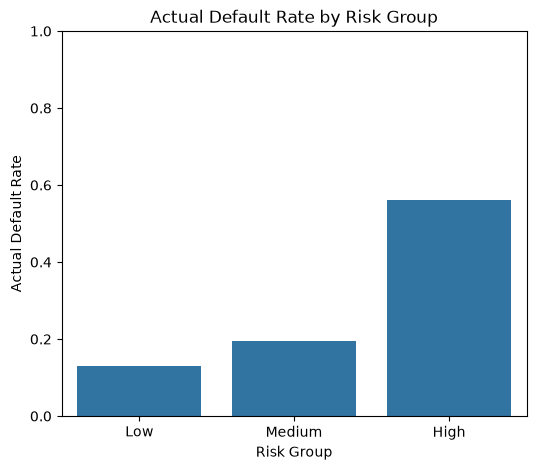

In [97]:
group_order = ["Low", "Medium", "High"]
default_rates = risk_summary.groupby("risk_group")["actual_default"].mean().reindex(group_order)

plt.figure(figsize=(6, 5))
sns.barplot(x=default_rates.index, y=default_rates.values, order=group_order)
plt.xlabel("Risk Group")
plt.ylabel("Actual Default Rate")
plt.title("Actual Default Rate by Risk Group")
plt.ylim(0, 1)
plt.savefig("../figures/risk_group_comparison.png", bbox_inches="tight", dpi=150)

The observed default rate increases monotonically across risk groups: 13.0% for Low risk, 19.5% for Medium risk, and 56.2% for High risk, compared to the overall portfolio default rate of ~22.1%. This confirms that the predicted probabilities meaningfully separate clients by actual risk, with the High risk group showing more than four times the default rate of the Low risk group. Management can prioritize review and risk-management actions on the High risk segment (1,614 clients), where more than half of clients are expected to default, while the Low risk segment (5,502 clients) requires minimal intervention.

In [63]:
lr_model.coef_

array([[-0.11010826,  0.03584029,  0.65373579,  0.10277926,  0.08443101,
         0.05739121,  0.0147264 ,  0.021704  , -0.30457794, -0.01399533,
         0.11299559,  0.03857064,  0.02085398,  0.02804271, -0.14829662,
        -0.25901644, -0.02375674, -0.0470577 , -0.02207295, -0.03895147,
        -0.1124927 ,  1.0350616 ,  0.91383489,  0.8788146 ,  0.04660546,
         0.4284935 ,  0.23032096,  0.45052998]])

In [79]:
fea_coef = pd.DataFrame(data={"coeficients":lr_model.coef_[0], "features":X_train_final.columns})
fea_coef.sort_values("coeficients", key=abs, ascending=False)

,coeficients,features
21,1.035062,EDUCATION_1
22,0.913835,EDUCATION_2
23,0.878815,EDUCATION_3
2,0.653736,PAY_0
27,0.450530,MARRIAGE_3
25,0.428493,MARRIAGE_1
8,-0.304578,BILL_AMT1
15,-0.259016,PAY_AMT2
26,0.230321,MARRIAGE_2
14,-0.148297,PAY_AMT1


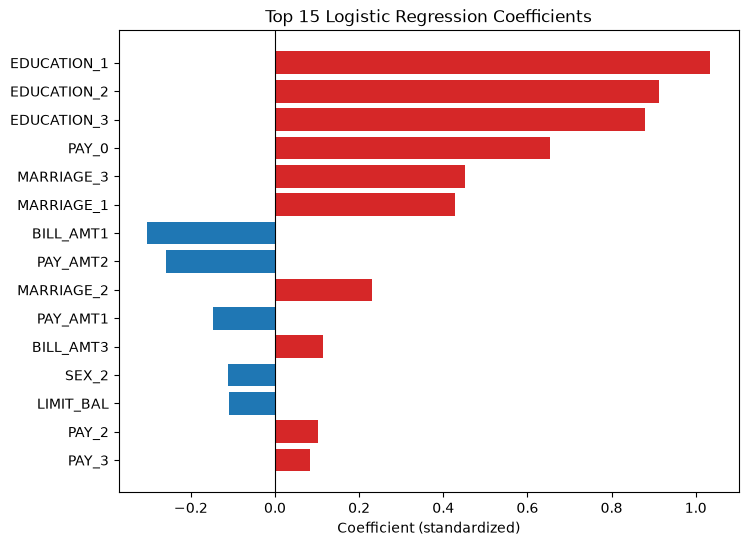

In [98]:
top_n = 15
top_features = fea_coef.sort_values("coeficients", key=abs, ascending=False).head(top_n)

plt.figure(figsize=(8, 6))
colors = ["#d62728" if c > 0 else "#1f77b4" for c in top_features["coeficients"]]
plt.barh(top_features["features"], top_features["coeficients"], color=colors)
plt.xlabel("Coefficient (standardized)")
plt.title(f"Top {top_n} Logistic Regression Coefficients")
plt.gca().invert_yaxis()
plt.axvline(0, color="black", linewidth=0.8)
plt.savefig("../figures/coefficient_importance.png", bbox_inches="tight", dpi=150)

## 13. Feature Importance & Interpretation (Q8)

The largest standardized coefficients belong to EDUCATION_1, EDUCATION_2, and EDUCATION_3, followed by PAY_0. However, this result should be interpreted with caution: these EDUCATION coefficients are measured relative to the dropped baseline category (EDUCATION = "Unknown"), which is a very small group (345 clients) that happened to show a 0% observed default rate in the data. This makes the baseline an unusually low-risk reference point, inflating the apparent effect of every other EDUCATION category rather than necessarily reflecting a strong real-world relationship between education and default risk.

Excluding this artifact, PAY_0 (the most recent repayment status) shows the strongest and most reliable positive association with default risk, consistent with the EDA findings that recent repayment behavior is the most informative signal. BILL_AMT1 and PAY_AMT2 show the largest negative coefficients, suggesting that clients with lower recent bill amounts or lower recent payments (potentially indicating limited credit usage or financial strain) are associated with different risk levels, though this relationship is more difficult to interpret directly.

These coefficients describe statistical associations learned from the training data, not causal relationships. Several predictors are likely correlated with one another — for example, PAY_0 through PAY_6 all capture repayment behavior across different months, and BILL_AMT1 through BILL_AMT6 are highly correlated bill amounts over time. This multicollinearity can make individual coefficients unstable or difficult to interpret in isolation, so conclusions should focus on broad patterns (e.g., recent repayment status matters more than older repayment history) rather than precise coefficient magnitudes for any single feature.

## 14. Management Summary (Q10)

**Business Problem:** The risk-analytics team needs to identify credit card clients most likely to default on their next payment, so that review and risk-management resources can be prioritized effectively.

**Which clients require closer review:** Based on the risk segmentation (Q7), the High risk group (1,614 clients, ~18% of the test set) shows an observed default rate of 56.2%, more than four times the portfolio average (~22.1%) and far above the Low risk group (13.0%). This segment should be prioritized for closer review and proactive risk-management action. The Medium risk group (1,884 clients, 19.5% observed default rate) warrants lighter monitoring, while the Low risk group (5,502 clients, 13.0%) requires minimal intervention.

**Supporting evidence:** The baseline Logistic Regression model achieves a ROC-AUC of 0.716 and a PR-AUC of 0.498, meaningfully above the random-classifier baseline (~0.221) for this imbalanced problem. The most informative predictor is the most recent repayment status (PAY_0), consistent with the exploratory analysis showing that recent payment behavior separates default and non-default clients more clearly than demographic or older repayment variables. The resulting risk groups show a clear, monotonic increase in observed default rate from Low to High, confirming the segmentation is practically meaningful.

**What the model cannot establish:** The model identifies statistical associations, not causal drivers of default — for example, a strong coefficient for a repayment or education variable does not mean changing that variable would change a client's risk. Several predictors (e.g., PAY_0 through PAY_6, BILL_AMT1 through BILL_AMT6) are correlated with one another, which can make individual coefficient magnitudes unstable or difficult to interpret in isolation. One coefficient (EDUCATION) is likely inflated by a small, unusually low-default baseline category rather than reflecting a genuine effect. The model also cannot account for changes in economic conditions or client behavior since the data was collected (Taiwan, April–September 2005), and its probabilities have not been calibrated for use as literal risk percentages.

**What would be required before real deployment:** (1) Validation on more recent and geographically broader data before any production use; (2) subgroup performance and fairness analysis across sensitive attributes (e.g., sex, age, education), given the ethical implications of using demographic variables in credit decisions; (3) probability calibration if predicted probabilities are to be used as literal risk estimates; (4) collaboration with the finance and risk teams to define the true business cost of false negatives versus false positives, replacing the simplifying cost assumption used in this project; and (5) ongoing monitoring for model drift as client behavior and economic conditions evolve.

This project is an educational risk-modeling prototype and does not constitute an approved credit-scoring system.

In [88]:
risk_output = pd.DataFrame({
    "client_id": X_test.index + 1,
    "predicted_probability": lr_y_proba,
    "risk_group": risk_groups.values
})

risk_output.head()

,client_id,predicted_probability,risk_group
0,8942,0.163374,Low
1,17619,0.232107,Medium
2,27896,0.082678,Low
3,16104,0.296908,Medium
4,4423,0.236792,Medium


In [89]:
import os

os.makedirs("../outputs", exist_ok=True)
risk_output.to_csv("../outputs/risk_groups.csv", index=False)